# EDA — creditcard.csv
**Adey Innovations Inc. | Fraud Detection | Week 5 & 6**

**Objective:** Explore the bank credit card transaction dataset. Features V1–V28 are already PCA-transformed and anonymized. This EDA focuses on Amount, Time, class distribution, and the relationship between these non-anonymized features and fraud.

---

## 0. Setup

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'axes.spines.top': False, 'axes.spines.right': False})

BLUE  = '#2E75B6'
CORAL = '#E95D4F'
GREEN = '#70AD47'

DATA_PATH = '../data/raw/creditcard.csv'
print('Setup complete.')

Setup complete.


---
## 1. Dataset Overview

In [53]:
cc = pd.read_csv(DATA_PATH)
print(f'Shape: {cc.shape[0]:,} rows × {cc.shape[1]} columns')
print(f'Features: Time, Amount, V1–V28 (PCA), Class')
print()
print('Missing values:', cc.isnull().sum().sum())
print('Duplicates:', cc.duplicated().sum())
cc.head(3)

Shape: 284,807 rows × 31 columns
Features: Time, Amount, V1–V28 (PCA), Class

Missing values: 0
Duplicates: 1081


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0


In [54]:
print('Descriptive statistics — Amount and Time:')
print(cc[['Time','Amount','Class']].describe().round(4))

Descriptive statistics — Amount and Time:
              Time       Amount        Class
count  284807.0000  284807.0000  284807.0000
mean    94813.8596      88.3496       0.0017
std     47488.1460     250.1201       0.0415
min         0.0000       0.0000       0.0000
25%     54201.5000       5.6000       0.0000
50%     84692.0000      22.0000       0.0000
75%    139320.5000      77.1650       0.0000
max    172792.0000   25691.1600       1.0000


---
## 2. Class Imbalance

Class distribution:
  Legitimate (0): 284,315  (99.8273%)
  Fraud      (1): 492  (0.1727%)
  Imbalance ratio: 578:1


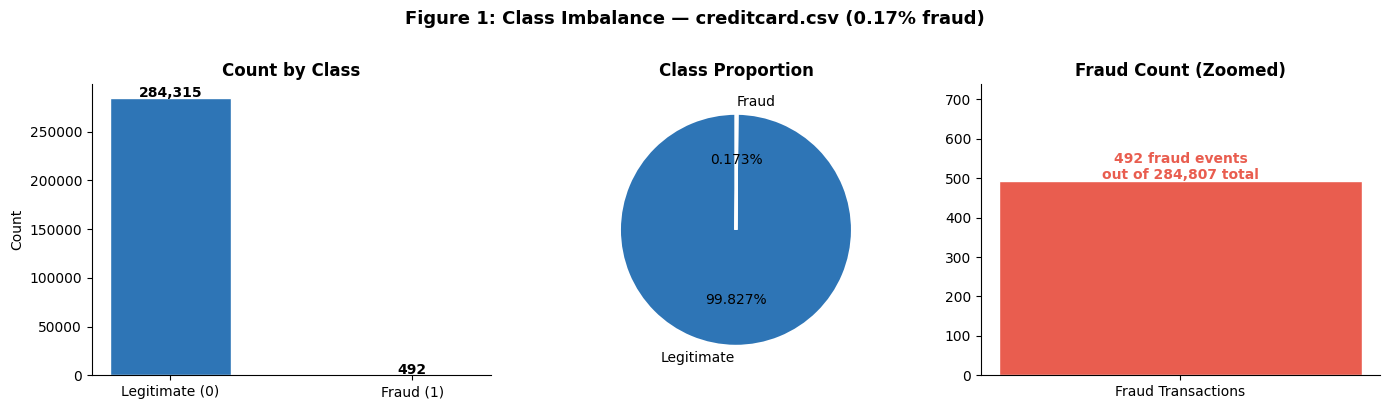

In [55]:
counts = cc['Class'].value_counts()
pcts   = cc['Class'].value_counts(normalize=True)*100

print('Class distribution:')
print(f'  Legitimate (0): {counts[0]:,}  ({pcts[0]:.4f}%)')
print(f'  Fraud      (1): {counts[1]:,}  ({pcts[1]:.4f}%)')
print(f'  Imbalance ratio: {counts[0]/counts[1]:.0f}:1')

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Bar
axes[0].bar(['Legitimate (0)','Fraud (1)'], [counts[0],counts[1]],
            color=[BLUE,CORAL], width=0.5, edgecolor='white')
for i,v in enumerate([counts[0],counts[1]]):
    axes[0].text(i, v+1000, f'{v:,}', ha='center', fontweight='bold')
axes[0].set_title('Count by Class', fontweight='bold')
axes[0].set_ylabel('Count')

# Pie
axes[1].pie([counts[0],counts[1]], labels=['Legitimate','Fraud'],
            colors=[BLUE,CORAL], autopct='%1.3f%%', startangle=90,
            wedgeprops={'edgecolor':'white','linewidth':2})
axes[1].set_title('Class Proportion', fontweight='bold')

# Fraud zoom
axes[2].bar(['Fraud Transactions'], [counts[1]], color=CORAL, width=0.3, edgecolor='white')
axes[2].text(0, counts[1]+5, f'{counts[1]} fraud events\nout of {len(cc):,} total',
             ha='center', fontweight='bold', fontsize=10, color=CORAL)
axes[2].set_title('Fraud Count (Zoomed)', fontweight='bold')
axes[2].set_ylim(0, counts[1]*1.5)

plt.suptitle('Figure 1: Class Imbalance — creditcard.csv (0.17% fraud)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../notebooks/figures/fig1_class_imbalance_cc.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3. Amount and Time Distributions

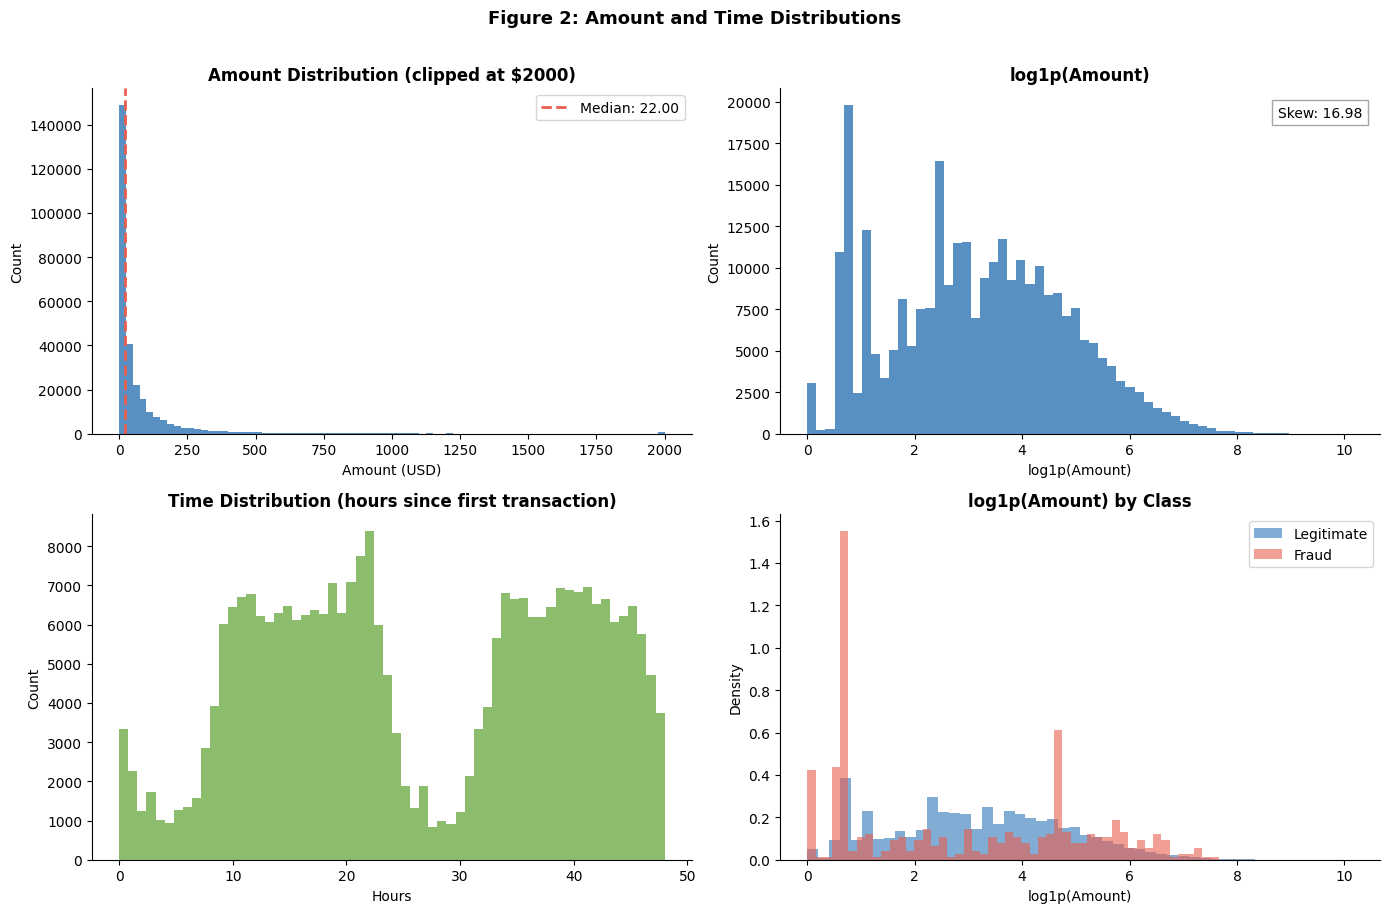

In [56]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Amount — raw
axes[0,0].hist(cc['Amount'].clip(0,2000), bins=80, color=BLUE, alpha=0.8, edgecolor='none')
axes[0,0].axvline(cc['Amount'].median(), color=CORAL, lw=2, linestyle='--',
                  label=f"Median: {cc['Amount'].median():.2f}")
axes[0,0].set_title('Amount Distribution (clipped at $2000)', fontweight='bold')
axes[0,0].set_xlabel('Amount (USD)'); axes[0,0].set_ylabel('Count')
axes[0,0].legend()

# Amount — log
axes[0,1].hist(np.log1p(cc['Amount']), bins=60, color=BLUE, alpha=0.8, edgecolor='none')
axes[0,1].set_title('log1p(Amount)', fontweight='bold')
axes[0,1].set_xlabel('log1p(Amount)'); axes[0,1].set_ylabel('Count')
axes[0,1].text(0.97,0.95,f"Skew: {cc['Amount'].skew():.2f}",
               transform=axes[0,1].transAxes, ha='right', va='top', fontsize=10,
               bbox=dict(fc='white', ec='gray', alpha=0.7))

# Time
axes[1,0].hist(cc['Time']/3600, bins=60, color=GREEN, alpha=0.8, edgecolor='none')
axes[1,0].set_title('Time Distribution (hours since first transaction)', fontweight='bold')
axes[1,0].set_xlabel('Hours'); axes[1,0].set_ylabel('Count')

# Amount by class
for cls, color, label in [(0, BLUE, 'Legitimate'), (1, CORAL, 'Fraud')]:
    axes[1,1].hist(np.log1p(cc[cc['Class']==cls]['Amount']), bins=50,
                   alpha=0.6, color=color, density=True, label=label, edgecolor='none')
axes[1,1].set_title('log1p(Amount) by Class', fontweight='bold')
axes[1,1].set_xlabel('log1p(Amount)'); axes[1,1].set_ylabel('Density')
axes[1,1].legend()

plt.suptitle('Figure 2: Amount and Time Distributions', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../notebooks/figures/fig2_amount_time_cc.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. PCA Feature Distributions (V1–V28)

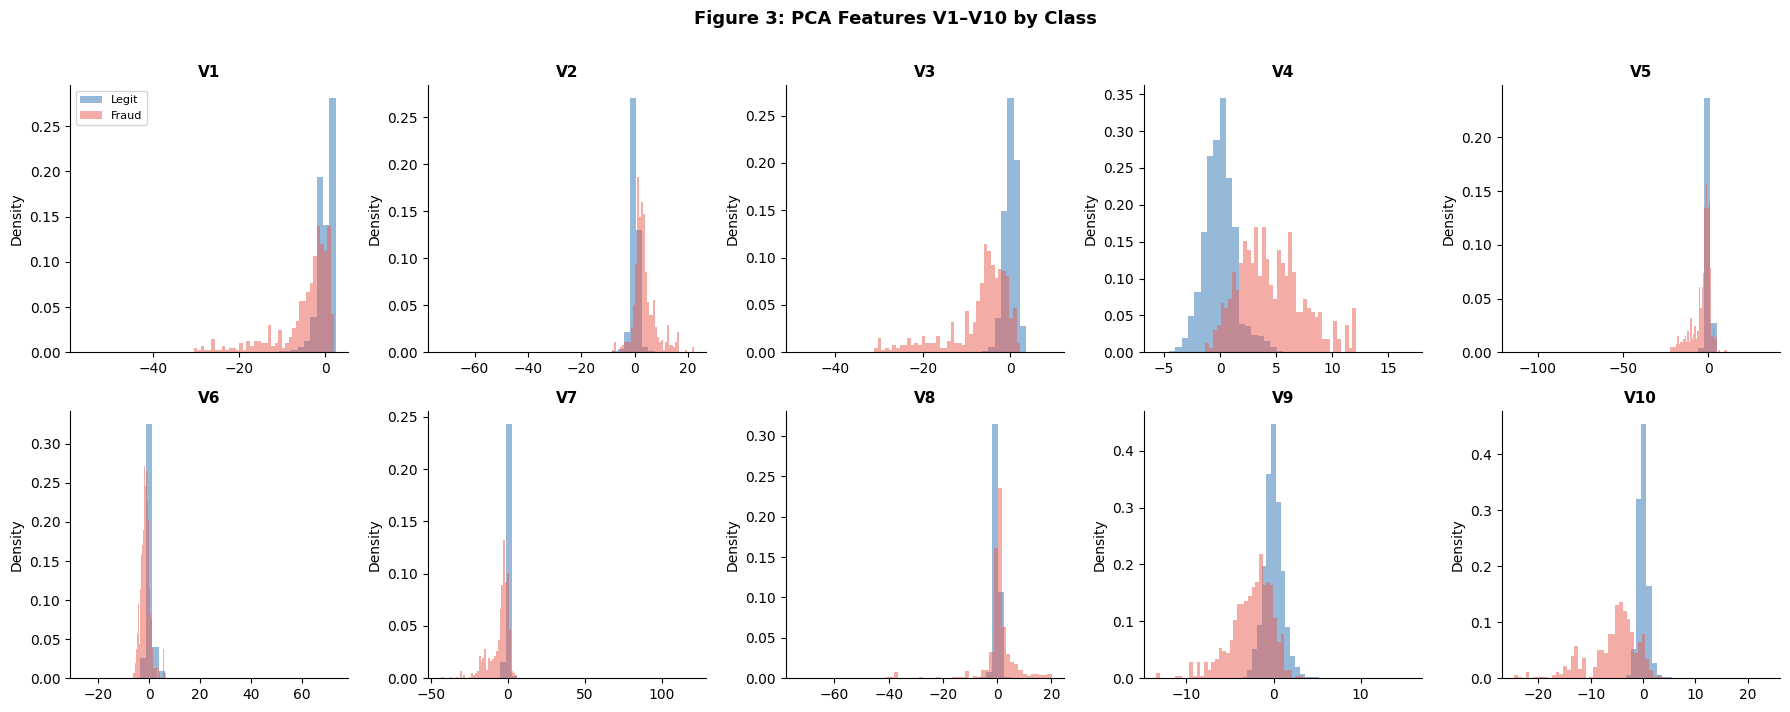

In [57]:
v_cols = [f'V{i}' for i in range(1, 29)]

# Distributions of V1-V10
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
for i, (col, ax) in enumerate(zip(v_cols[:10], axes.flatten())):
    for cls, color, label in [(0, BLUE, 'Legit'), (1, CORAL, 'Fraud')]:
        ax.hist(cc[cc['Class']==cls][col], bins=40, alpha=0.5,
                color=color, density=True, label=label, edgecolor='none')
    ax.set_title(col, fontweight='bold', fontsize=11)
    ax.set_ylabel('Density')
    if i == 0:
        ax.legend(fontsize=8)

plt.suptitle('Figure 3: PCA Features V1–V10 by Class', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../notebooks/figures/fig3_pca_features_cc.png', dpi=150, bbox_inches='tight')
plt.show()

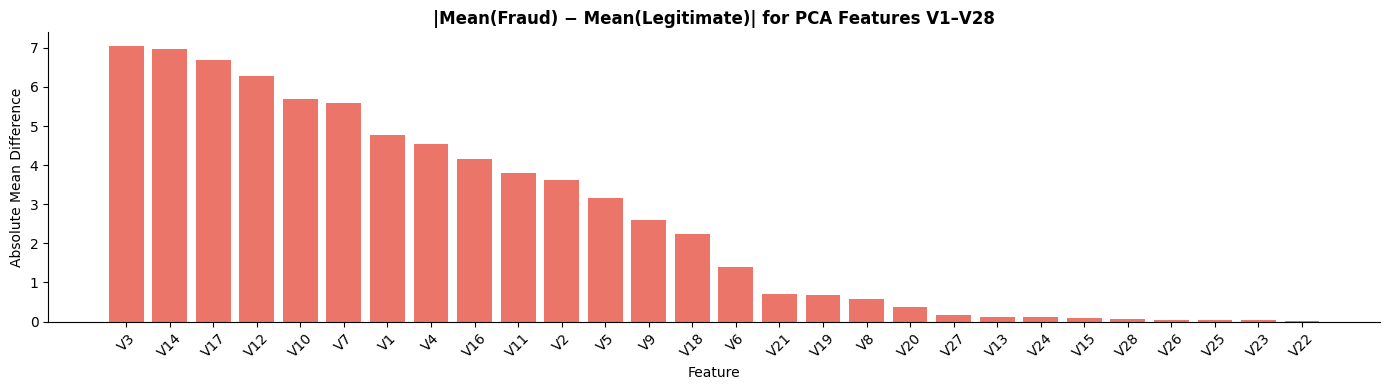

Top 10 most discriminative PCA features:
V3     7.0455
V14    6.9838
V17    6.6774
V12    6.2702
V10    5.6867
V7     5.5784
V1     4.7802
V4     4.5499
V16    4.1471
V11    3.8067
dtype: float64


In [58]:
# Feature means by class — identify most discriminative PCA features
fraud_means = cc[cc['Class']==1][v_cols].mean()
legit_means = cc[cc['Class']==0][v_cols].mean()
mean_diff   = (fraud_means - legit_means).abs().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(mean_diff.index, mean_diff.values, color=CORAL, alpha=0.85, edgecolor='none')
ax.set_title('|Mean(Fraud) − Mean(Legitimate)| for PCA Features V1–V28', fontweight='bold')
ax.set_xlabel('Feature')
ax.set_ylabel('Absolute Mean Difference')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../notebooks/figures/fig4_pca_mean_diff_cc.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 10 most discriminative PCA features:')
print(mean_diff.head(10).round(4))

---
## 5. Temporal Fraud Pattern

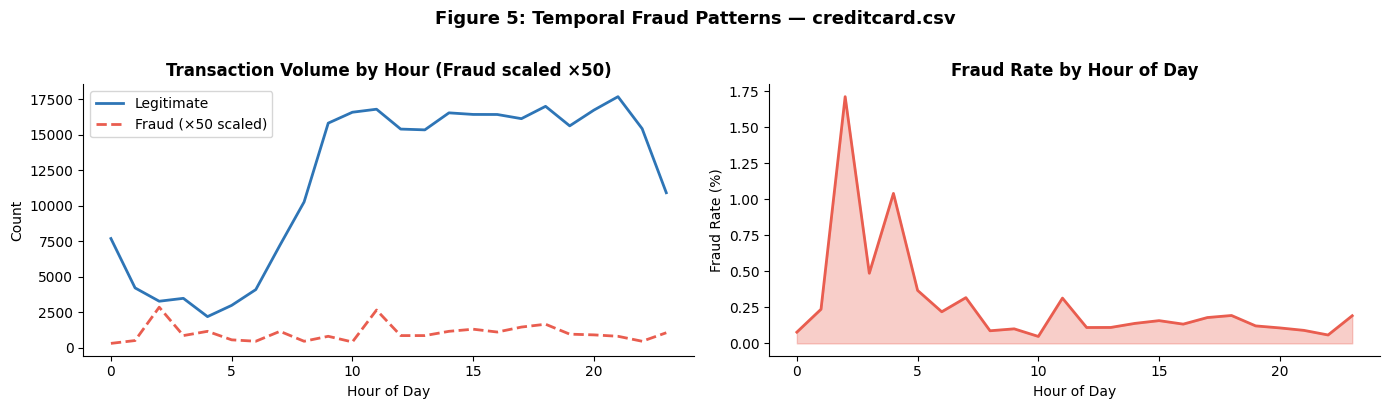

In [60]:
cc['hour_bin'] = (cc['Time'] // 3600 % 24).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

hour_counts = cc.groupby(['hour_bin','Class']).size().unstack(fill_value=0)
axes[0].plot(hour_counts.index, hour_counts[0], color=BLUE, lw=2, label='Legitimate')
axes[0].plot(hour_counts.index, hour_counts[1]*50, color=CORAL, lw=2, linestyle='--',
             label='Fraud (×50 scaled)')
axes[0].set_title('Transaction Volume by Hour (Fraud scaled ×50)', fontweight='bold')
axes[0].set_xlabel('Hour of Day'); axes[0].set_ylabel('Count')
axes[0].legend()

hour_fraud_rate = cc.groupby('hour_bin')['Class'].mean() * 100
axes[1].fill_between(hour_fraud_rate.index, hour_fraud_rate.values, alpha=0.3, color=CORAL)
axes[1].plot(hour_fraud_rate.index, hour_fraud_rate.values, color=CORAL, lw=2)
axes[1].set_title('Fraud Rate by Hour of Day', fontweight='bold')
axes[1].set_xlabel('Hour of Day'); axes[1].set_ylabel('Fraud Rate (%)')

plt.suptitle('Figure 5: Temporal Fraud Patterns — creditcard.csv', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../notebooks/figures/fig5_temporal_cc.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Top EDA Insights — creditcard.csv

### Insight 1 — Extreme Class Imbalance (0.17% fraud)
492 fraud transactions out of 284,807 — a 577:1 imbalance ratio. This is the most extreme imbalance in the project. Standard accuracy is completely uninformative. SMOTE on training data, combined with class_weight='balanced', is mandatory. Model selection must be based entirely on Precision-Recall AUC and F1.

### Insight 2 — V4, V11, V12, V14, V17 Are Most Discriminative
The absolute mean difference between fraud and legitimate classes is largest for these PCA components. While the original features are anonymized, these components should receive the highest feature importance in any tree-based model, and their distributions should be monitored for drift in production.

### Insight 3 — Fraud Transactions Cluster at Lower Amounts
Fraudulent transactions tend to have lower amounts than legitimate ones — the log1p(Amount) distribution for fraud peaks at lower values. This is a well-documented pattern: fraudsters often test stolen cards with small amounts before escalating. Amount is therefore a useful feature despite its skewness.

### Insight 4 — Temporal Bimodal Pattern
Transaction volume shows a clear bimodal daily pattern (two peaks approximately 12 hours apart), consistent with the dataset spanning two consecutive days. Fraud rate fluctuates with time — the `hour_bin` feature is worth engineering and including.

### Insight 5 — No Missing Values, But 1,081 Duplicates
The dataset has zero missing values but 1,081 fully duplicate rows (0.38%). These must be dropped before training to prevent data leakage — a duplicate row that appears in both train and test sets would inflate evaluation metrics artificially.